In [263]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from warnings import filterwarnings
filterwarnings('ignore')


from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

 

In [264]:
df = pd.read_csv('Telco-Customer-Churn.csv')
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


### Understanding Dataset

In [265]:
print('There are =',df.shape)

There are = (7043, 21)


In [266]:
print('Total datapoints=',df.size)

Total datapoints= 147903


In [267]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [268]:
df.tail(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7033,9767-FFLEM,Male,0,No,No,38,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Credit card (automatic),69.50,2625.25,No
7034,0639-TSIQW,Female,0,No,No,67,Yes,Yes,Fiber optic,Yes,...,Yes,No,Yes,No,Month-to-month,Yes,Credit card (automatic),102.95,6886.25,Yes
7035,8456-QDAVC,Male,0,No,No,19,Yes,No,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),78.70,1495.1,No
7036,7750-EYXWZ,Female,0,No,No,12,No,No phone service,DSL,No,...,Yes,Yes,Yes,Yes,One year,No,Electronic check,60.65,743.3,No
7037,2569-WGERO,Female,0,No,No,72,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [269]:
df.sample()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
1356,0196-JTUQI,Female,0,No,No,9,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Credit card (automatic),75.2,633.85,No


In [270]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [271]:
df.dtypes.to_frame(name='Column Data Types')

,Column Data Types
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [272]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [273]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [274]:
df['InternetService'].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [275]:
df['PaymentMethod'].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [276]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Cleaning Dataset

In [277]:
df.drop(columns =['customerID','SeniorCitizen','Dependents'],inplace = True)

In [278]:
df

,gender,Partner,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,Yes,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,Female,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,Female,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,Yes,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [279]:
df.duplicated().sum()

np.int64(34)

In [280]:
df.drop_duplicates(inplace = True)

In [281]:
df.duplicated().sum()

np.int64(0)

In [282]:
df.size

126162

In [283]:
df['TotalCharges'] = df['TotalCharges'].str.replace(' ','0')

In [284]:
df['TotalCharges'] = df['TotalCharges'].astype(float)

In [285]:
df.dtypes

gender               object
Partner              object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [286]:
 df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

In [287]:
df

,gender,Partner,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,Yes,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,0
7039,Female,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,0
7040,Female,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0
7041,Male,Yes,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,1


### Business Queries

##### 1) how many customers are churned vs not?

In [288]:
df['Churn'].value_counts()

Churn
0    5159
1    1850
Name: count, dtype: int64

##### 2)what is the percentage of churn?

In [289]:
df['Churn'].value_counts(normalize=True) * 100

Churn
0    73.605365
1    26.394635
Name: proportion, dtype: float64

#### 3) what is average total charges by churn?

In [290]:
df.groupby('Churn')['TotalCharges'].mean()

Churn
0    2557.257831
1    1547.008216
Name: TotalCharges, dtype: float64

#### 4)Does churn differ between male and female customers?

In [291]:
churn_gender = pd.crosstab(df['gender'], df['Churn'], normalize='index') * 100
print(churn_gender)

Churn           0          1
gender                      
Female  73.245109  26.754891
Male    73.959808  26.040192


#### 5)Top five highest paying custombers?

In [292]:
df.sort_values(by='TotalCharges', ascending=False).head()

,gender,Partner,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
4610,Male,Yes,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,One year,Yes,Bank transfer (automatic),117.80,8684.80,1
4586,Female,Yes,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),118.75,8672.45,0
6768,Female,Yes,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),117.50,8670.10,0
5347,Male,Yes,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),116.95,8594.40,0
2187,Male,Yes,71,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,116.25,8564.75,0


#### 6)Customers with low tenure (<12 months)

In [293]:

low_tenure = df[df['tenure'] < 12]
low_tenure['Churn'].value_counts()

Churn
0    1055
1     980
Name: count, dtype: int64

#### 7)Top factors affecting churn (correlation-like insight)

In [294]:
df_encoded = df.copy()

for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = df_encoded[col].astype('category').cat.codes

df_encoded.corr()['Churn'].sort_values(ascending=False)

Churn               1.000000
MonthlyCharges      0.195128
PaperlessBilling    0.190602
PaymentMethod       0.105771
MultipleLines       0.041250
PhoneService        0.011746
gender             -0.008107
StreamingTV        -0.033266
StreamingMovies    -0.035162
InternetService    -0.047267
Partner            -0.148757
DeviceProtection   -0.175851
OnlineBackup       -0.193330
TotalCharges       -0.196445
TechSupport        -0.281055
OnlineSecurity     -0.287927
tenure             -0.350946
Contract           -0.396337
Name: Churn, dtype: float64

#### 8) which internent service churn more?

In [295]:
churn_internet = pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100
print(churn_internet)

Churn                    0          1
InternetService                      
DSL              81.159420  18.840580
Fiber optic      58.295528  41.704472
No               92.838196   7.161804


#### 9)Do new customers churn more?

In [296]:
df['tenure_group'] = pd.cut(df['tenure'], bins=[0,12,24,48,72], 
                           labels=['0-12','12-24','24-48','48-72'])

churn_tenure = pd.crosstab(df['tenure_group'], df['Churn'], normalize='index') * 100
print(churn_tenure)

Churn                 0          1
tenure_group                      
0-12          52.452125  47.547875
12-24         71.289062  28.710938
24-48         79.611041  20.388959
48-72         90.486824   9.513176


#### 10)What is the total revenue generated by churned vs non-churned customers?

In [297]:
df.groupby('Churn')['TotalCharges'].sum()

Churn
0    13192893.15
1     2861965.20
Name: TotalCharges, dtype: float64

<br><br><br><br>
###  Future Engineering

#### 1)Tenure group

In [298]:
def tenure_group(x):
    if x <= 12:
        return "0-1 Year"
    elif x <= 24:
        return "1-2 Years"
    elif x <= 48:
        return "2-4 Years"
    else:
        return "4+ Years"

df['TenureGroup'] = df['tenure'].apply(tenure_group)

                                

#### 2)Average Monthly Spend 

In [299]:
df['AvgMonthlySpend'] = df['TotalCharges'] / (df['tenure'] + 1)

#### 3)Total Services Count 

In [300]:
services = ['OnlineSecurity','OnlineBackup','DeviceProtection',
            'TechSupport','StreamingTV','StreamingMovies']

df['TotalServices'] = df[services].apply(lambda x: (x=='Yes').sum(), axis=1)

#### 4) High Value Customer Flag

In [301]:
df['HighValue'] = np.where(df['MonthlyCharges'] > df['MonthlyCharges'].mean(), 1, 0)

#### 5)Contract Type Mapping 

In [302]:
df['Contract_Mapped'] = df['Contract'].map({
    'Month-to-month': 0,
    'One year': 1,
    'Two year': 2
})

<br><br><br><br>
### Data Visualization

### TenureGroup vs Churn --CountPlot

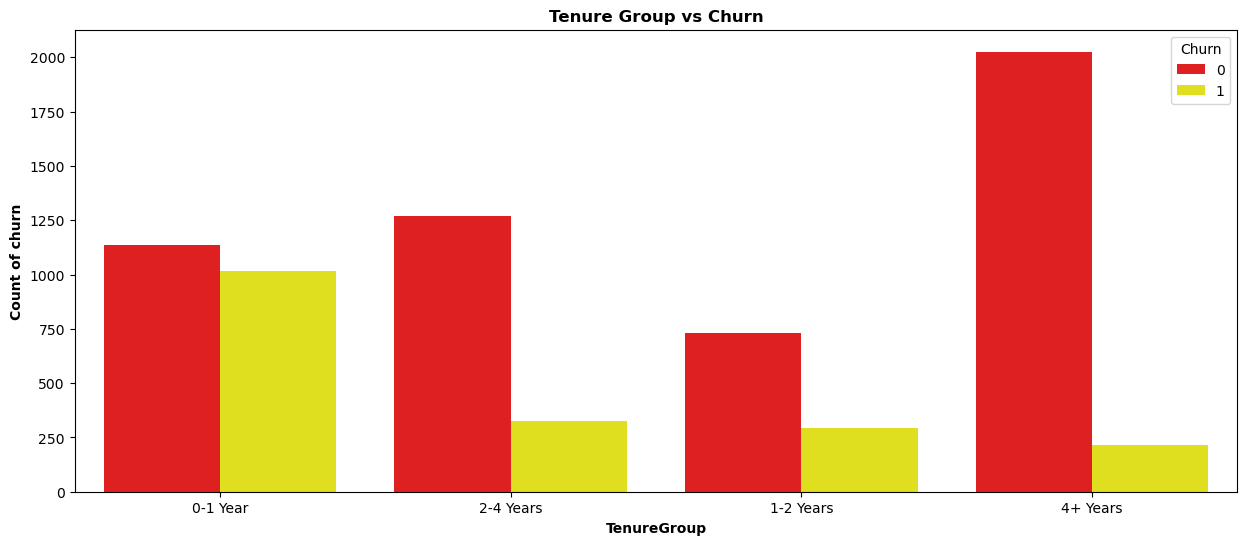

In [303]:
# Countplot
plt.figure(figsize=(15,6))
color =['red','yellow']
sns.countplot(x='TenureGroup', hue='Churn', data=df, palette=color)
plt.xlabel('TenureGroup',fontweight = 'bold')
plt.ylabel('Count of churn',fontweight = 'bold')

plt.title("Tenure Group vs Churn",fontweight = 'bold')
plt.show()

#### Above graph shows that The Customer who has highest tenure ,customer churn risk is low

### Catplot-Churn vs TenureGroup based on Gender

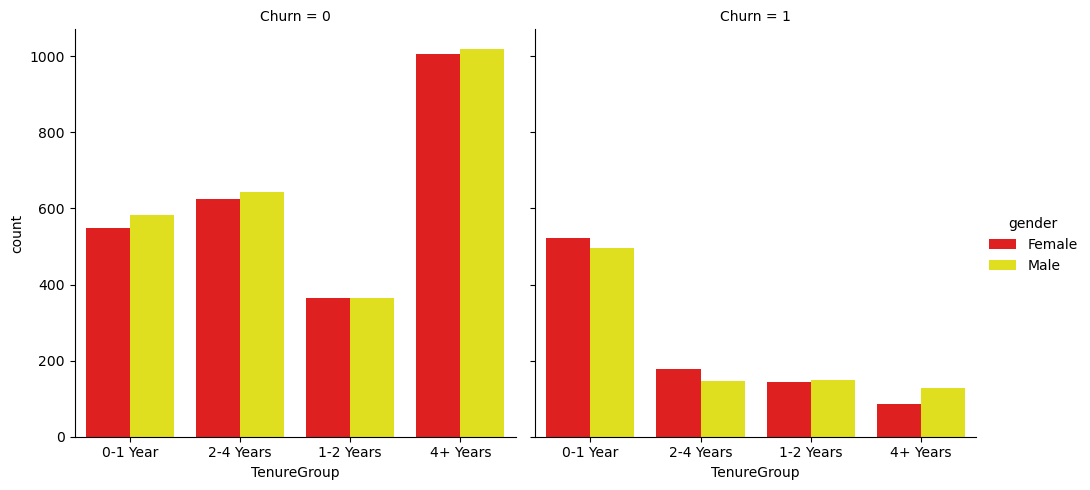

In [304]:
#catplot
sns.catplot(x = 'TenureGroup', hue ='gender',data = df, col = 'Churn',kind = 'count',palette = color)
plt.show()

In [305]:
df.dtypes

gender                object
Partner               object
tenure                 int64
PhoneService          object
MultipleLines         object
InternetService       object
OnlineSecurity        object
OnlineBackup          object
DeviceProtection      object
TechSupport           object
StreamingTV           object
StreamingMovies       object
Contract              object
PaperlessBilling      object
PaymentMethod         object
MonthlyCharges       float64
TotalCharges         float64
Churn                  int64
tenure_group        category
TenureGroup           object
AvgMonthlySpend      float64
TotalServices          int64
HighValue              int64
Contract_Mapped        int64
dtype: object

### HighValue vs Avg Tenure -- using BarChart

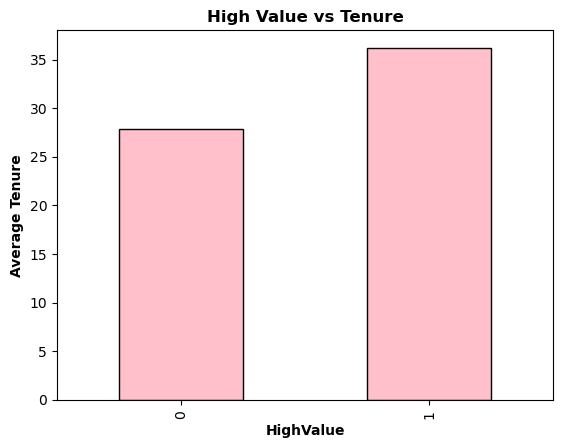

In [307]:

bar_data = df.groupby('HighValue')['tenure'].mean()


bar_data.plot(kind='bar',color='pink',edgecolor='black')

plt.xlabel('HighValue',fontweight='bold')
plt.ylabel('Average Tenure',fontweight='bold')
plt.title('High Value vs Tenure',fontweight='bold')

plt.show()

##### High-value customers may not always stay long

#### Histogram

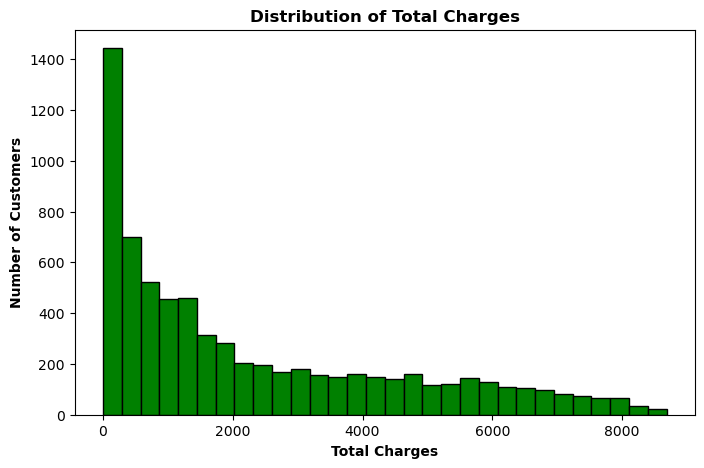

In [310]:
plt.figure(figsize=(8,5))

plt.hist(df['TotalCharges'], 
         bins=30, 
         color='green', 
         edgecolor='black')

plt.title("Distribution of Total Charges", fontweight='bold')
plt.xlabel("Total Charges", fontweight='bold')
plt.ylabel("Number of Customers", fontweight='bold')

plt.show()

##### Most customers have lower total charges

#### Line Chart

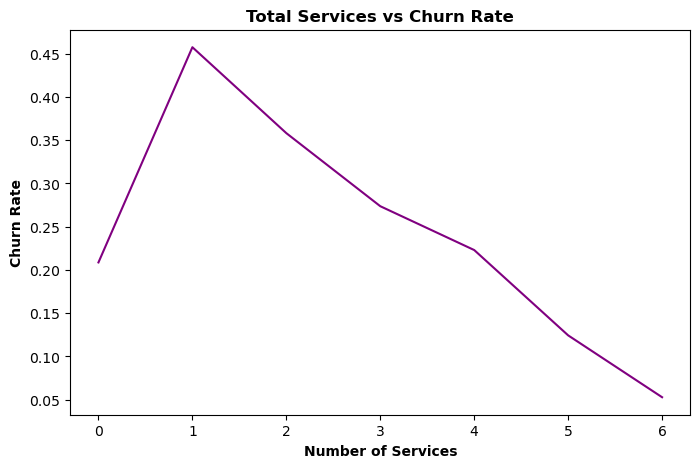

In [312]:
services_churn = df.groupby('TotalServices')['Churn'].mean()

plt.figure(figsize=(8,5))

plt.plot(services_churn.index, 
         services_churn.values, 
         color='purple')

plt.title("Total Services vs Churn Rate", fontweight='bold')
plt.xlabel("Number of Services", fontweight='bold')
plt.ylabel("Churn Rate", fontweight='bold')

plt.show()

#### Churn decreases as services increase

#### Churn Distribution by Tenure -- PIE CHART

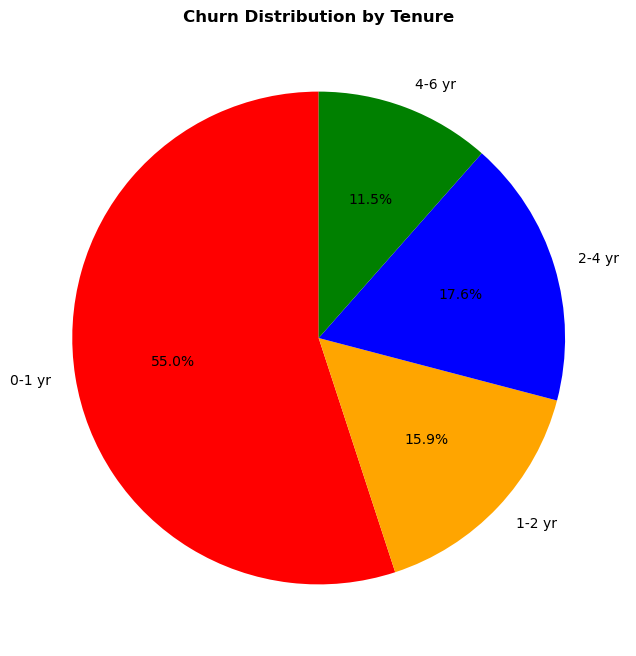

In [313]:

df['TenureRange'] = pd.cut(df['tenure'], bins=[0,12,24,48,72],
                          labels=['0-1 yr','1-2 yr','2-4 yr','4-6 yr'])
tenure_churn = df.groupby('TenureRange')['Churn'].sum()
plt.figure(figsize=(8,8))
colors = ['red','orange','blue','green']
plt.pie(tenure_churn,
        labels=tenure_churn.index,
        autopct='%1.1f%%',
        colors=colors,
        startangle=90)
plt.title('Churn Distribution by Tenure', fontweight='bold')
plt.show()

### Model Training

In [ ]:
# Convert Categorical Data - Numerical
df = pd.get_dummies(df, drop_first=True)

In [ ]:
# Split Features and Target
x = df.drop('Churn', axis=1)
y = df['Churn']

In [ ]:
x

In [ ]:
y

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

print('X-Train:',x_train.shape)
print('Y-Train:',y_train.shape)
print('X-Test:',x_test.shape)
print('Y-Test:',y_test.shape)

#### 1)logistic Regression

In [ ]:

model=LogisticRegression()
model.fit(x_train, y_train)
model


In [229]:
y_pred=model.predict(x_test)
print('Accuracy Score :', round(accuracy_score(y_pred,y_test)*100,2))
acc_lr =round(accuracy_score(y_pred, y_test)*100,2)


Accuracy Score : 74.61


#### 2) Decission Tree

In [230]:
model=DecisionTreeClassifier()
model.fit(x_train, y_train)
y_pred=model.predict(x_test)
print('Accuracy Score :', round(accuracy_score(y_pred, y_test)*100, 2))
acc_dt=round(accuracy_score(y_pred, y_test)*100,2)

Accuracy Score : 74.18


#### RandomForestClassifier

In [231]:
model=RandomForestClassifier()
model.fit(x_train, y_train)
y_pred=model.predict(x_test)
print('Accuracy Score :', round(accuracy_score(y_pred, y_test)*100, 2))
acc_rf=round(accuracy_score(y_pred, y_test)*100,2)

Accuracy Score : 78.67


##### Support Vector Machine

In [232]:
model=SVC()
model.fit(x_train, y_train)
y_pred=model.predict(x_test)
print('Accuracy Score :', round(accuracy_score(y_pred, y_test)*100, 2))
acc_svm=round(accuracy_score(y_pred, y_test)*100,2)

Accuracy Score : 72.54


#### 5) KNN-K Nearest Neighbor Algorithm

In [233]:
model=KNeighborsClassifier()
model.fit(x_train, y_train)
y_pred=model.predict(x_test)
print('Accuracy Score :', round(accuracy_score(y_pred, y_test)*100, 2))
acc_knn=round(accuracy_score(y_pred, y_test)*100,2)

Accuracy Score : 77.1


#### 6) XGBoost Classifier

In [234]:
model=XGBClassifier()
model.fit(x_train, y_train)
y_pred=model.predict(x_test)
print('Accuracy Score :', round(accuracy_score(y_pred, y_test)*100, 2))
acc_xgb=round(accuracy_score(y_pred, y_test)*100,2)

Accuracy Score : 79.53


#### To Compare All Models

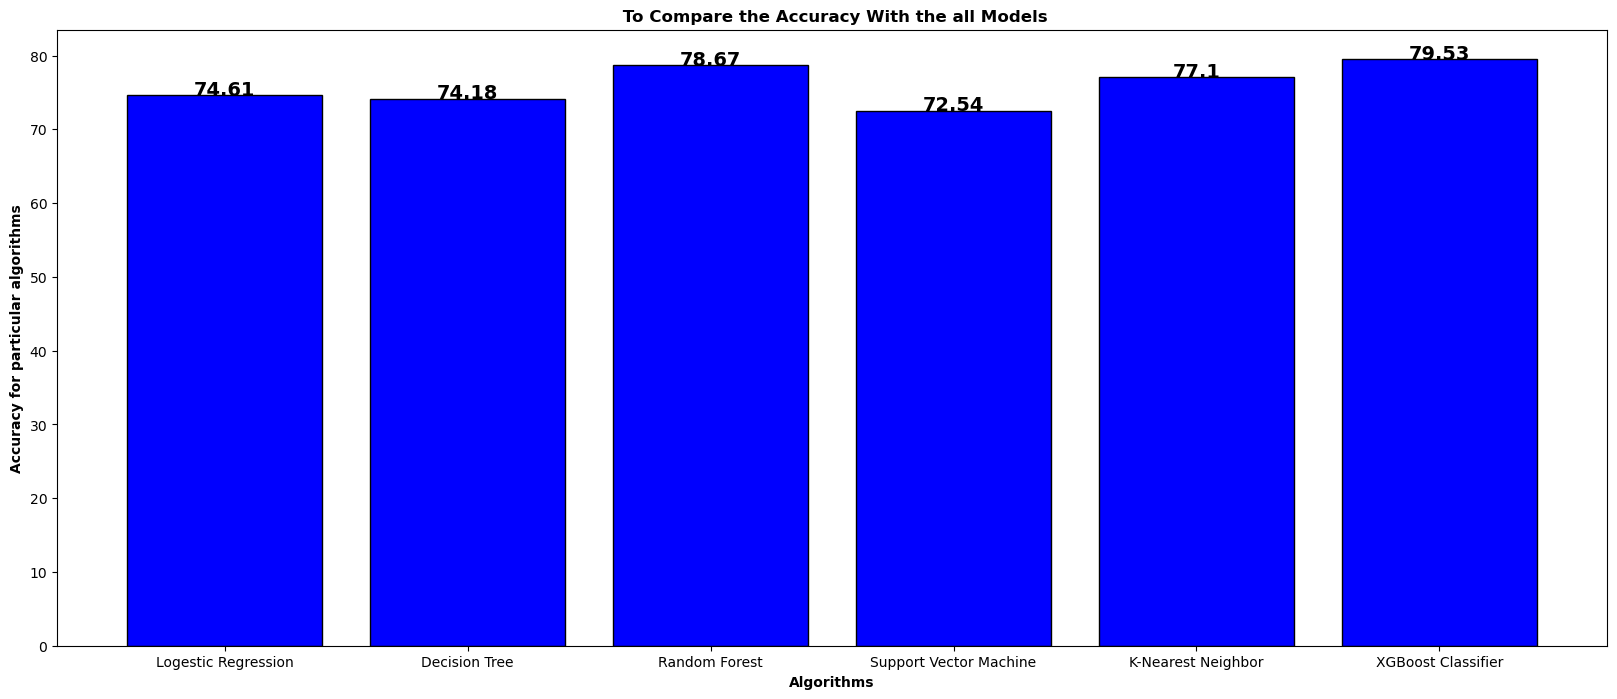

In [238]:
models=['Logestic Regression', 
        'Decision Tree', 
        'Random Forest',
        'Support Vector Machine',
        'K-Nearest Neighbor',
        'XGBoost Classifier']

accuracies = [acc_lr, acc_dt, acc_rf, acc_svm, acc_knn, acc_xgb]

import matplotlib.pyplot as plt

plt.figure(figsize=(20,8))
plt.bar(models, accuracies, color='blue', edgecolor='black', lw=1 )
plt.title(' To Compare the Accuracy With the all Models', fontweight='bold')
plt.xlabel('Algorithms', fontweight='bold')
plt.ylabel('Accuracy for particular algorithms', fontweight='bold')

for i in range(len(accuracies)):
    plt.text(i, accuracies[i],accuracies[i], 
            ha='center', 
            fontweight='bold', fontsize=14)

### Final Model Evaluation

In [254]:
from sklearn.metrics import accuracy_score, classification_report

print("Final Model Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Final Model Accuracy: 0.7952924393723253

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1017
           1       0.67      0.51      0.58       385

    accuracy                           0.80      1402
   macro avg       0.75      0.71      0.72      1402
weighted avg       0.78      0.80      0.79      1402



In [258]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred))

[[918  99]
 [188 197]]


#### Feature Importanace

In [243]:

importance = model.feature_importances_

# Convert to DataFrame
feat_imp = pd.Series(importance, index=X.columns)

# Sort values
feat_imp = feat_imp.sort_values(ascending=False)

# Show top 10
feat_imp.head(10)

InternetService_Fiber optic       0.359419
HighValue                         0.264150
InternetService_No                0.069764
PhoneService_Yes                  0.025739
tenure                            0.023906
PaperlessBilling_Yes              0.017940
PaymentMethod_Electronic check    0.017820
OnlineSecurity_Yes                0.017571
MultipleLines_Yes                 0.016746
TechSupport_Yes                   0.016184
dtype: float32

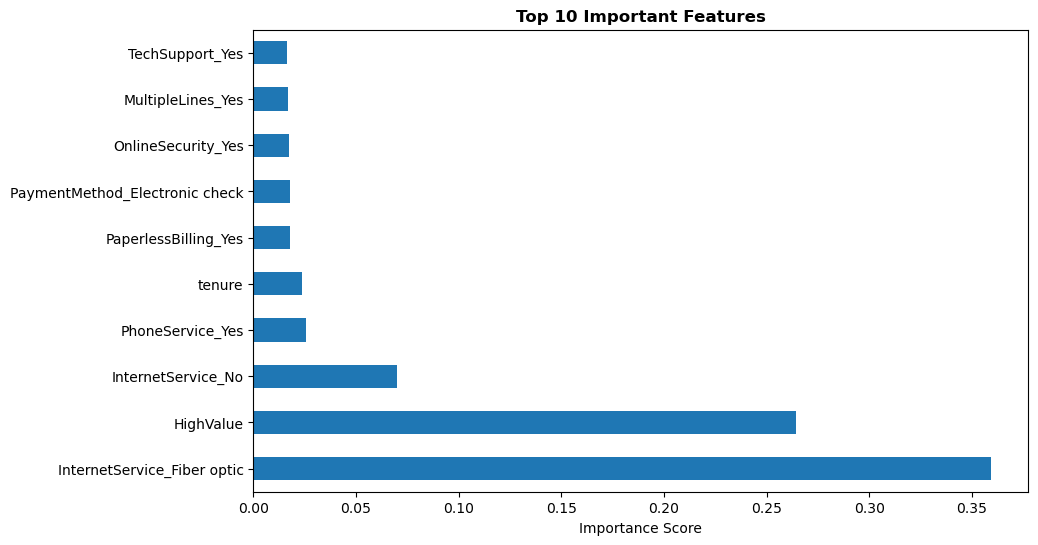

In [244]:
plt.figure(figsize=(10,6))

feat_imp.head(10).plot(kind='barh')

plt.title("Top 10 Important Features", fontweight='bold')
plt.xlabel("Importance Score")

plt.show()

#### Final Business Insights 
- Customers with low tenure are more likely to churn
- Fiber optic users show higher churn behavior
- High monthly charges increase churn probability
- Contract type plays a major role in retention